# D10 + Lapatinib: Per-Donor Panels

Generates per-donor panels for the D10 Lapatinib dataset:

- **Secretory PC / Enterocyte highlight panels** — per donor (Veres style)
- **EEC-by-donor** — single UMAP colored by donor identity
- **Overall D10** — UMAP by donor + per-donor cell type breakdowns (scanpy & Veres)
- **EEC subtypes** — per-donor EEC subtype breakdowns (scanpy & Veres)

All figures are saved to `figures/d10-lapa-donors/`.

In [ ]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import sys
from pathlib import Path

_p = Path(".").resolve()
while not (_p / "src" / "config.py").exists() and _p != _p.parent:
    _p = _p.parent
sys.path.insert(0, str(_p))

from src.config import ANALYSIS_DIR, FIGURES_DIR
from src.palette import celltype_palette
from src.vis import (
    setup_matplotlib_params,
    plot_veres_panel,
    plot_veres_panel_highlight,
    make_label_params,
    prepare_for_scatter,
)

setup_matplotlib_params()


def plot_veres_triptych(
    adata, split_key, donors, label_key, label_order,
    palette, title=None, save=None, dpi=600,
):
    """Three Veres-style UMAP scatters side-by-side with one shared legend."""
    cats = label_order
    lp = make_label_params(cats, palette=palette)

    mm = 25.4
    panel_w = 89 / 2 / mm
    fig_w = panel_w * 3 + 0.6
    fig_h = panel_w * 0.75
    fig = plt.figure(figsize=(fig_w, fig_h), dpi=dpi)

    gs = gridspec.GridSpec(1, 4, figure=fig, width_ratios=[1, 1, 1, 0.4],
                           wspace=0.05)

    s_black, s_white, s_type = 4, 2, 1.5

    for i, donor in enumerate(donors):
        ad = adata[adata.obs[split_key] == donor].copy()
        X = ad.obsm["X_umap"]
        labels = ad.obs[label_key].astype(str).values
        proj, rgb = prepare_for_scatter(X, labels, lp)

        ax = fig.add_subplot(gs[0, i])
        ax.scatter(proj[:, 0], proj[:, 1], c="k", s=s_black, edgecolor="none", rasterized=True)
        ax.scatter(proj[:, 0], proj[:, 1], c="w", s=s_white, edgecolor="none", rasterized=True)
        ax.scatter(proj[:, 0], proj[:, 1], c=rgb, s=s_type, alpha=0.7, edgecolor="none", rasterized=True)
        ax.set_xticks([]); ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)
        ax.set_xlabel(f"{donor} ({ad.n_obs:,})", fontsize=6, fontweight="bold", labelpad=4)
        ax.set_ylabel("")
        ax.set_title("")

    # Shared legend
    ax_leg = fig.add_subplot(gs[0, 3])
    ax_leg.axis("off")
    present = [c for c in cats if c in set(adata.obs[label_key].astype(str))]
    for j, lb in enumerate(present):
        y = 1.0 - j * 0.09
        ax_leg.scatter(0.05, y, s=18, c=lp[lb]["color"].reshape(1, -1),
                       transform=ax_leg.transAxes, clip_on=False, zorder=5)
        ax_leg.text(0.18, y, lb, fontsize=5, va="center",
                    transform=ax_leg.transAxes, clip_on=False)

    if title:
        fig.suptitle(title, fontsize=7, fontweight="extra bold", y=1.02)

    if save:
        fig.savefig(save, dpi=dpi, transparent=True, bbox_inches="tight")
    return fig

## Load data

In [ ]:
# Full D10_Lapa dataset (CellAssign predictions)
adata_full = sc.read_h5ad(ANALYSIS_DIR / "data-objects/cellassign" / "d10_lapa_predictions.h5ad")

LABEL_KEY = "initial_cellassign_prediction"
DONOR_KEY = "participant"

# Keep only real donors (drop Doublet / Negative)
REAL_DONORS = ["H329", "H896", "H897"]
adata = adata_full[adata_full.obs[DONOR_KEY].isin(REAL_DONORS)].copy()

print(f"Full dataset: {adata_full.n_obs:,} cells")
print(f"After filtering to real donors: {adata.n_obs:,} cells")
print(f"Donors: {REAL_DONORS}")
print()
print(adata.obs.groupby(DONOR_KEY, observed=True)[LABEL_KEY].value_counts().unstack(fill_value=0))

In [ ]:
# EEC subclustered object (kNN-labelled, v3 labels)
eec_path = ANALYSIS_DIR / "data-objects/labelled" / "knn_EECs_egfDuod_D10_Lapa_DZ.h5ad"
adata_eec_full = sc.read_h5ad(eec_path)

EEC_LABEL_KEY = "granular_EEC_label_v3"
adata_eec = adata_eec_full[adata_eec_full.obs[DONOR_KEY].isin(REAL_DONORS)].copy()

print(f"EEC subset: {adata_eec.n_obs:,} cells (from {eec_path.name})")
print(f"Label key: {EEC_LABEL_KEY}")
print(f"Donors: {sorted(adata_eec.obs[DONOR_KEY].unique())}")
print()
print(adata_eec.obs[DONOR_KEY].value_counts())
print()
print(adata_eec.obs[EEC_LABEL_KEY].value_counts())

## Setup

In [ ]:
SAVE_DIR = FIGURES_DIR / "d10-lapa-donors"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

LABEL_ORDER = [
    "EECs", "Secretory PCs", "Goblet cells",
    "Proliferating PCs", "ISCs", "PCs", "Enterocytes",
]

EEC_LABEL_ORDER = [
    "X cells", "D cells", "I cells",
    "K cells", "Enterochromaffin cells", "Early EECs",
]

# EEC subtype palette — matches Veres cycle from 1.4_EEC_subanalysis
# (Set1_9 in label_order, with Early EECs overridden to grey)
eec_palette = {
    "X cells":                "#e41a1c",  # red
    "D cells":                "#377eb8",  # blue
    "I cells":                "#4daf4a",  # green
    "K cells":                "#984ea3",  # purple
    "Enterochromaffin cells": "#ff7f00",  # orange
    "Early EECs":             "#999999",  # grey
}

DPI = 600

## Secretory PC highlight panels (per donor)

Donor H329: 8,239 cells


/Users/stanleydale/user_generated/breault-lab/single-cell/src/vis.py:398: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


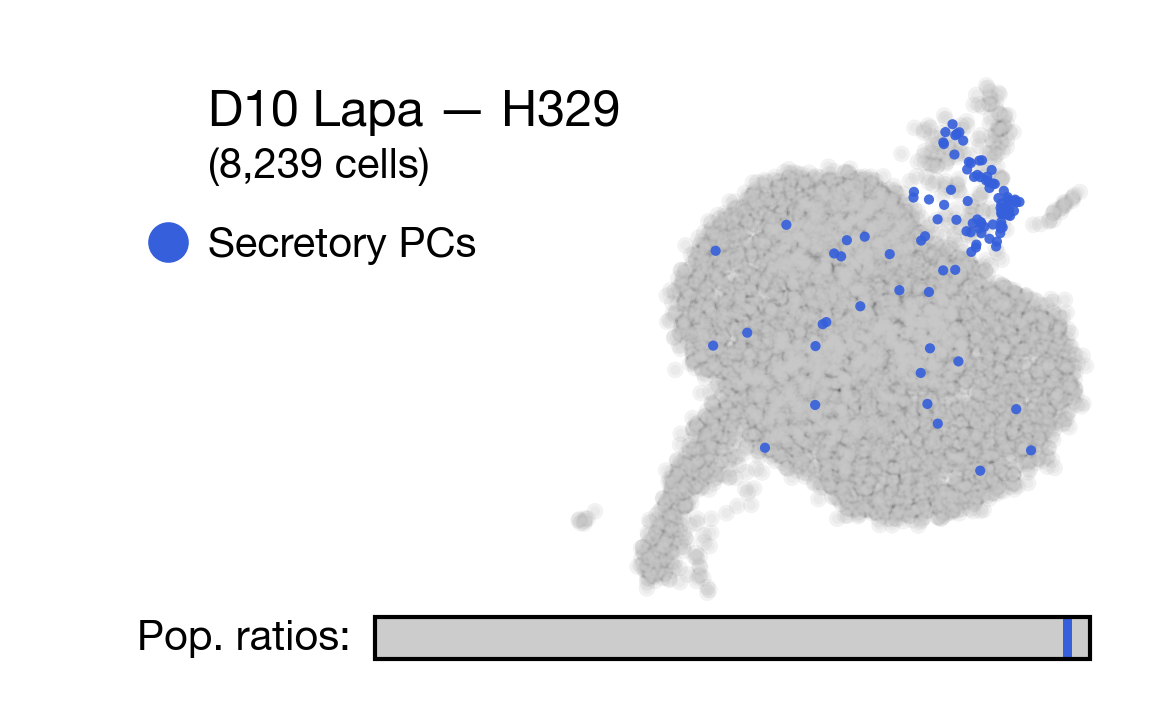

Donor H896: 11,508 cells


/Users/stanleydale/user_generated/breault-lab/single-cell/src/vis.py:398: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


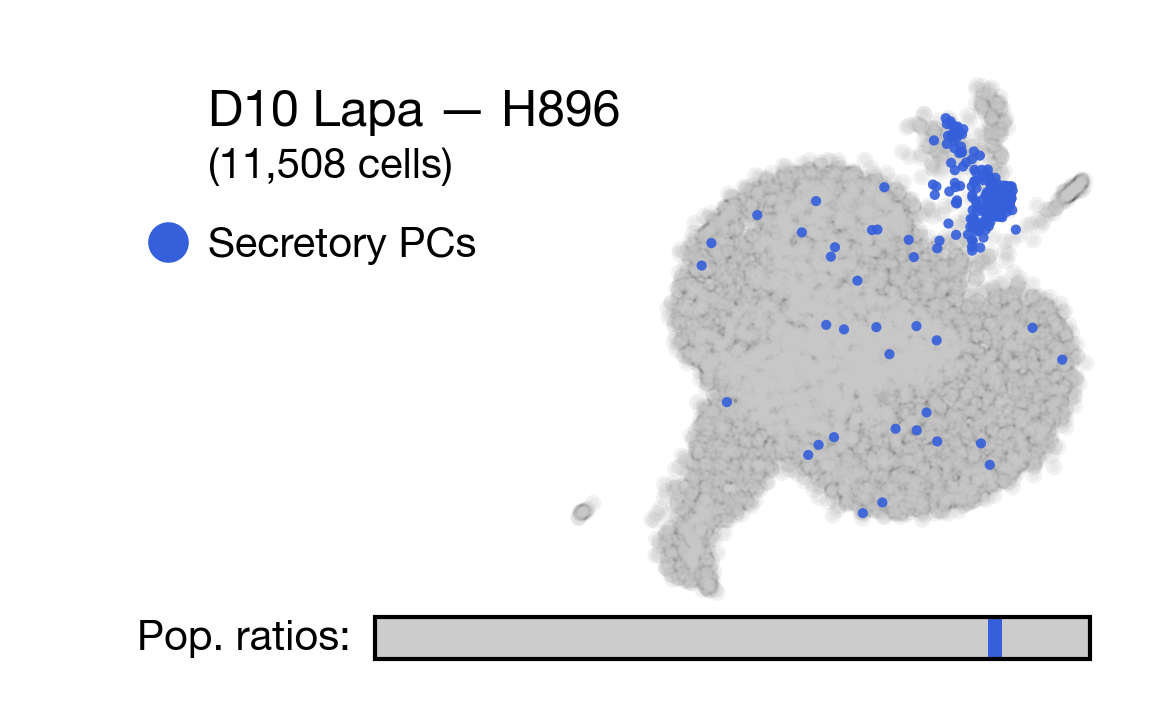

Donor H897: 9,708 cells


/Users/stanleydale/user_generated/breault-lab/single-cell/src/vis.py:398: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


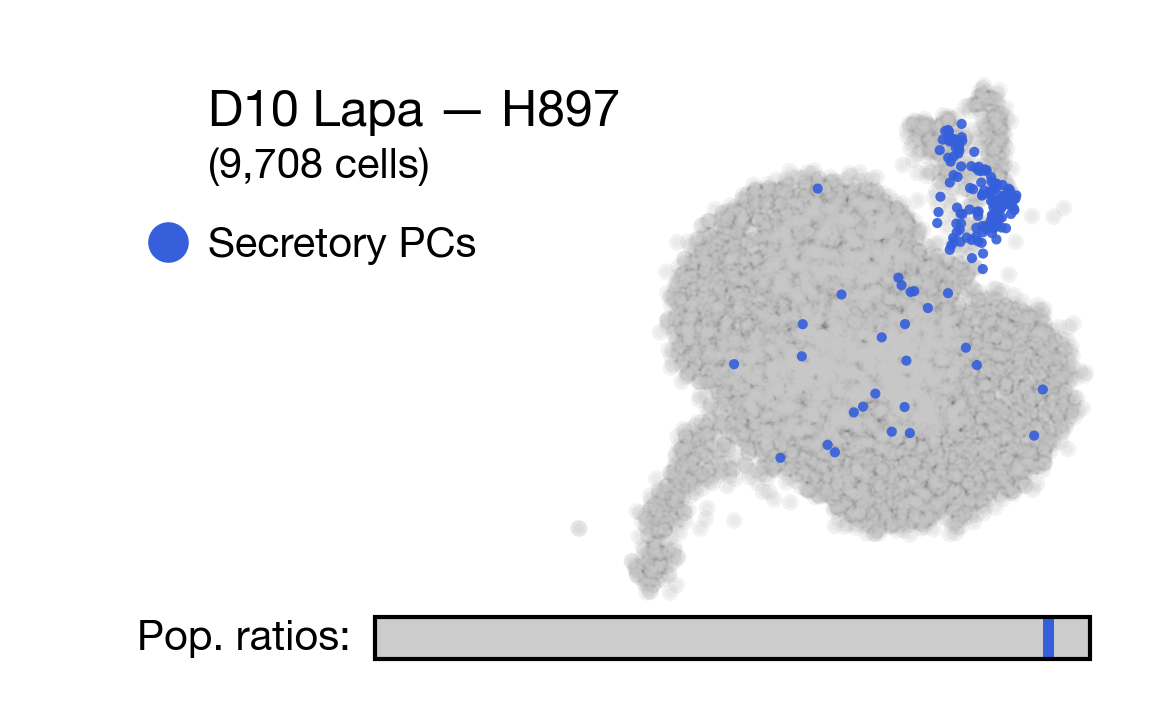

In [5]:
for donor in REAL_DONORS:
    ad = adata[adata.obs[DONOR_KEY] == donor].copy()
    print(f"Donor {donor}: {ad.n_obs:,} cells")

    fig = plot_veres_panel_highlight(
        ad,
        label_key=LABEL_KEY,
        highlight_label="Secretory PCs",
        stage_text=f"D10 Lapa \u2014 {donor}",
        palette=celltype_palette,
        save=SAVE_DIR / f"secretory_pcs_{donor}.pdf",
        dpi=DPI,
    )
    plt.show()
    plt.close(fig)

## Enterocyte highlight panels (per donor)

Donor H329: 8,239 cells


/Users/stanleydale/user_generated/breault-lab/single-cell/src/vis.py:398: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


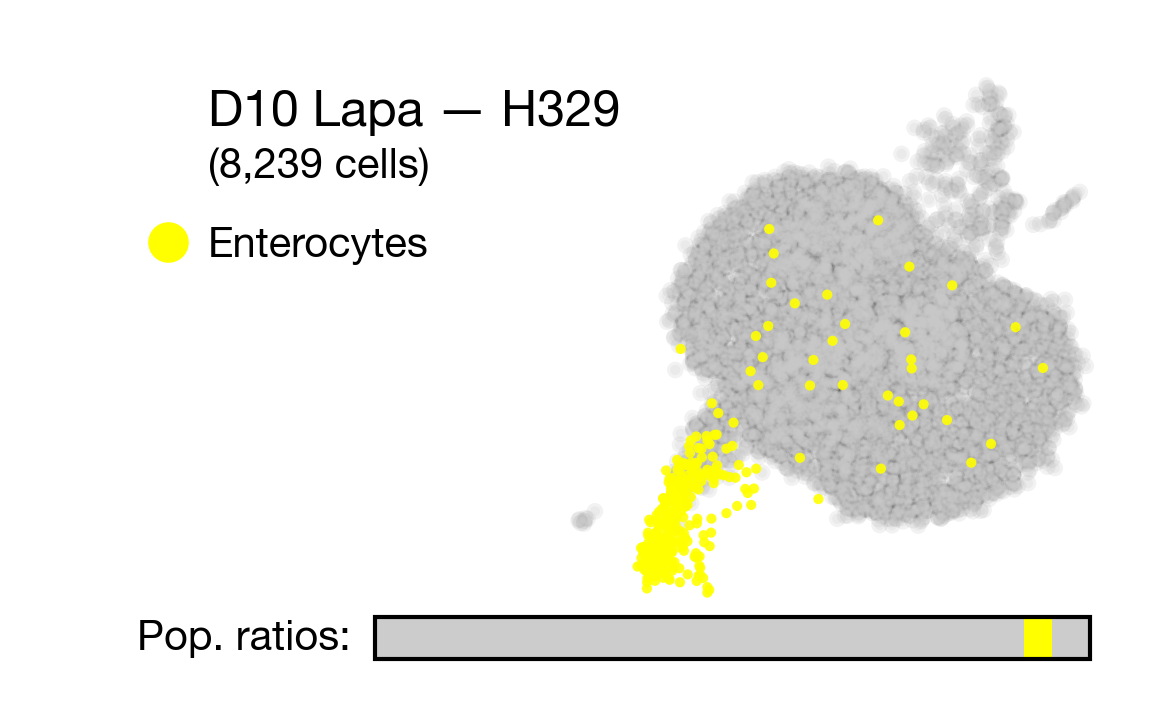

Donor H896: 11,508 cells


/Users/stanleydale/user_generated/breault-lab/single-cell/src/vis.py:398: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


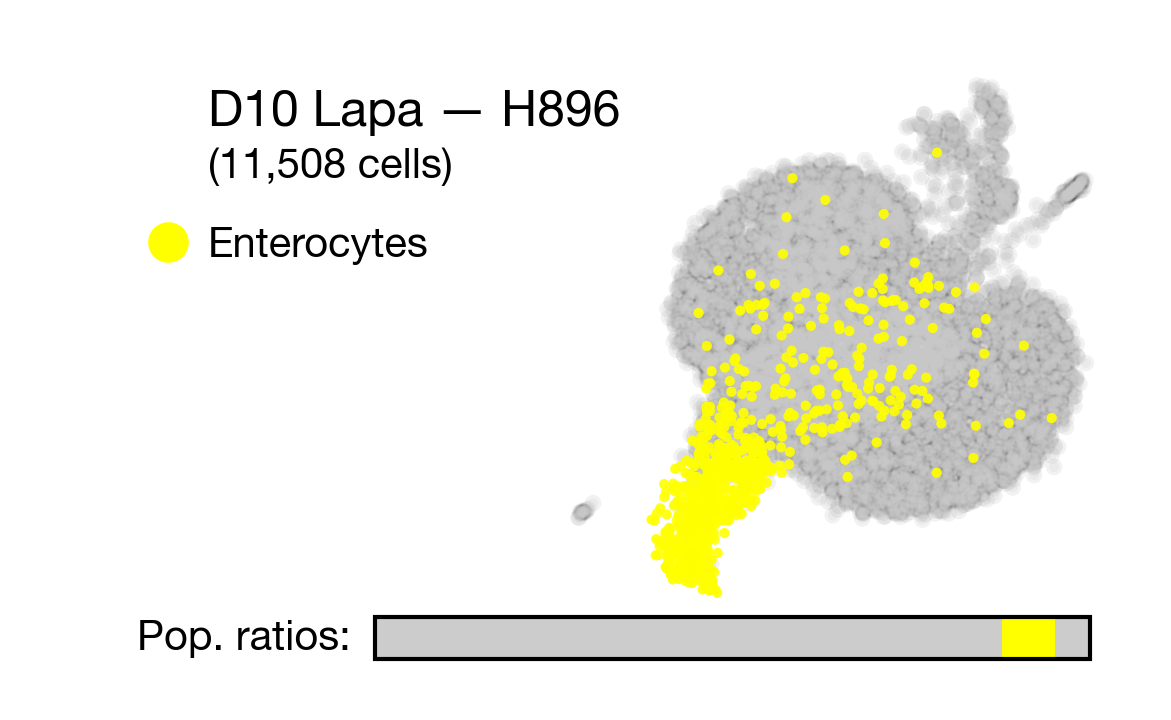

Donor H897: 9,708 cells


/Users/stanleydale/user_generated/breault-lab/single-cell/src/vis.py:398: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


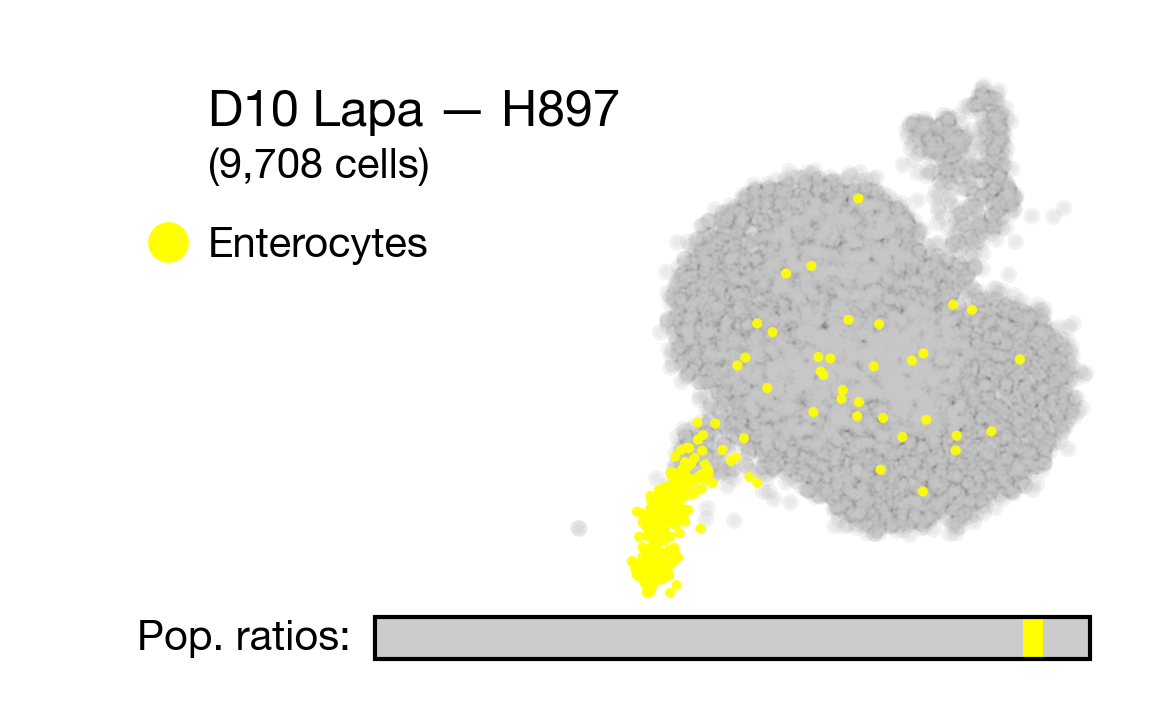

In [6]:
for donor in REAL_DONORS:
    ad = adata[adata.obs[DONOR_KEY] == donor].copy()
    print(f"Donor {donor}: {ad.n_obs:,} cells")

    fig = plot_veres_panel_highlight(
        ad,
        label_key=LABEL_KEY,
        highlight_label="Enterocytes",
        stage_text=f"D10 Lapa \u2014 {donor}",
        palette=celltype_palette,
        save=SAVE_DIR / f"enterocytes_{donor}.pdf",
        dpi=DPI,
    )
    plt.show()
    plt.close(fig)

## EEC subtype panel — colored by donor

In [ ]:
# Donor color palette (Dark2 — saturated teal / orange / purple)
from palettable.colorbrewer.qualitative import Dark2_3
from matplotlib.colors import to_hex

donor_palette = {
    d: to_hex([c / 255.0 for c in rgb])
    for d, rgb in zip(REAL_DONORS, Dark2_3.colors)
}
print("Donor palette:", donor_palette)

fig = plot_veres_panel(
    adata_eec,
    label_key=DONOR_KEY,
    stage_text="D10 EECs — by donor",
    label_order=REAL_DONORS,
    ratio_order=REAL_DONORS,
    palette=donor_palette,
    save=SAVE_DIR / "eec_by_donor.pdf",
    dpi=DPI,
)
plt.show()
plt.close(fig)

## Overall D10 — All donors UMAP (scanpy)

In [ ]:
sc.pl.umap(
    adata, color=DONOR_KEY, palette=donor_palette,
    title="D10 Lapa — All donors", frameon=False,
    save="_d10_all_donors.pdf",
)

## Overall D10 — All donors UMAP (Veres)

In [ ]:
fig = plot_veres_panel(
    adata,
    label_key=DONOR_KEY,
    stage_text="D10 Lapa — All donors",
    label_order=REAL_DONORS,
    ratio_order=REAL_DONORS,
    palette=donor_palette,
    save=SAVE_DIR / "d10_all_donors_veres.pdf",
    dpi=DPI,
)
plt.show()
plt.close(fig)

## Overall D10 — Per-donor cell types (scanpy)

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, donor in zip(axes, REAL_DONORS):
    ad = adata[adata.obs[DONOR_KEY] == donor].copy()
    sc.pl.umap(
        ad, color=LABEL_KEY, palette=celltype_palette,
        title=donor,
        frameon=False, show=False, ax=ax,
    )
    ax.set_title(donor, fontsize=18, fontweight="bold")
plt.tight_layout()
plt.savefig(SAVE_DIR / "d10_per_donor_celltypes_scanpy_v2.pdf", dpi=DPI, bbox_inches="tight")
plt.show()

## Overall D10 — Per-donor cell types (Veres)

In [ ]:
for donor in REAL_DONORS:
    ad = adata[adata.obs[DONOR_KEY] == donor].copy()
    print(f"Donor {donor}: {ad.n_obs:,} cells")

    fig = plot_veres_panel(
        ad,
        label_key=LABEL_KEY,
        stage_text=f"D10 Lapa — {donor}",
        label_order=LABEL_ORDER,
        ratio_order=LABEL_ORDER,
        palette=celltype_palette,
        save=SAVE_DIR / f"d10_celltypes_{donor}_veres.pdf",
        dpi=DPI,
    )
    plt.show()
    plt.close(fig)

## Overall D10 — Per-donor cell types (Veres triptych)

In [ ]:
fig = plot_veres_triptych(
    adata, split_key=DONOR_KEY, donors=REAL_DONORS,
    label_key=LABEL_KEY, label_order=LABEL_ORDER,
    palette=celltype_palette, title="D10 Lapa — Cell types by donor",
    save=SAVE_DIR / "d10_per_donor_celltypes_triptych.pdf", dpi=DPI,
)
plt.show()
plt.close(fig)

## EEC subtypes — Per-donor (scanpy)

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, donor in zip(axes, REAL_DONORS):
    ad = adata_eec[adata_eec.obs[DONOR_KEY] == donor].copy()
    sc.pl.umap(
        ad, color=EEC_LABEL_KEY, palette=eec_palette,
        title=f"EEC subtypes — {donor} ({ad.n_obs:,} cells)",
        frameon=False, show=False, ax=ax,
    )
plt.tight_layout()
plt.savefig(SAVE_DIR / "eec_per_donor_subtypes_scanpy.pdf", dpi=DPI, bbox_inches="tight")
plt.show()

## EEC subtypes — Per-donor (Veres)

In [ ]:
for donor in REAL_DONORS:
    ad = adata_eec[adata_eec.obs[DONOR_KEY] == donor].copy()
    print(f"Donor {donor}: {ad.n_obs:,} EECs")

    fig = plot_veres_panel(
        ad,
        label_key=EEC_LABEL_KEY,
        stage_text=f"D10 EECs — {donor}",
        label_order=EEC_LABEL_ORDER,
        ratio_order=EEC_LABEL_ORDER,
        palette=eec_palette,
        save=SAVE_DIR / f"eec_subtypes_{donor}_veres.pdf",
        dpi=DPI,
    )
    plt.show()
    plt.close(fig)

## EEC subtypes — Per-donor (Veres triptych)

In [ ]:
fig = plot_veres_triptych(
    adata_eec, split_key=DONOR_KEY, donors=REAL_DONORS,
    label_key=EEC_LABEL_KEY, label_order=EEC_LABEL_ORDER,
    palette=eec_palette, title="D10 EEC subtypes by donor",
    save=SAVE_DIR / "eec_per_donor_subtypes_triptych.pdf", dpi=DPI,
)
plt.show()
plt.close(fig)

## Summary

In [8]:
saved = sorted(SAVE_DIR.glob("*.pdf"))
print(f"Saved {len(saved)} figures to {SAVE_DIR}:")
for f in saved:
    print(f"  {f.name}")

Saved 7 figures to /Users/stanleydale/user_generated/breault-lab/single-cell/figures/d10-lapa-donors:
  eec_by_donor.pdf
  enterocytes_H329.pdf
  enterocytes_H896.pdf
  enterocytes_H897.pdf
  secretory_pcs_H329.pdf
  secretory_pcs_H896.pdf
  secretory_pcs_H897.pdf
